# **1. Perkenalan Dataset**


# Adult Income Dataset

Dataset ini berasal dari UCI Machine Learning Repository dan digunakan untuk memprediksi apakah pendapatan seseorang melebihi 50.000 USD per tahun berdasarkan karakteristik demografis, pendidikan, pekerjaan, dan kondisi sosial ekonomi.

Sumber Dataset:
https://archive.ics.uci.edu/dataset/2/adult

Dataset memiliki 48.842 observasi dan 14 fitur yang terdiri dari atribut numerik maupun kategorikal.

Target klasifikasi:

* <=50K : Pendapatan kurang dari atau sama dengan 50.000 USD per tahun
* > 50K : Pendapatan lebih dari 50.000 USD per tahun

Fitur yang tersedia meliputi:

* Age
* Workclass
* Education
* Education-num
* Marital-status
* Occupation
* Relationship
* Race
* Sex
* Capital-gain
* Capital-loss
* Hours-per-week
* Native-country

Tujuan analisis adalah melakukan Exploratory Data Analysis (EDA) dan preprocessing data sehingga dataset siap digunakan untuk proses pelatihan model machine learning. Proses preprocessing mencakup penanganan missing value, penghapusan data duplikat, encoding fitur kategorikal, standarisasi fitur numerik, serta penyimpanan dataset hasil preprocessing untuk kebutuhan pelatihan model dan implementasi pipeline MLOps.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import joblib

import warnings
warnings.filterwarnings("ignore")

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

Load Dataset

In [4]:
column_names = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df = pd.read_csv(
    "adult.data",
    names=column_names,
    header=None,
    skipinitialspace=True
)

Preview Data

In [5]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Shape Dataset

In [6]:
df.shape

(32561, 15)

Informasi Dataset

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Statistik Deskriptif

In [8]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


Missing Value

In [9]:
df.replace("?", np.nan, inplace=True)

df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

Persentase Missing Value

In [10]:
(df.isnull().sum() / len(df)) * 100

age               0.000000
workclass         5.638647
fnlwgt            0.000000
education         0.000000
education_num     0.000000
marital_status    0.000000
occupation        5.660146
relationship      0.000000
race              0.000000
sex               0.000000
capital_gain      0.000000
capital_loss      0.000000
hours_per_week    0.000000
native_country    1.790486
income            0.000000
dtype: float64

Duplikasi

In [11]:
df.duplicated().sum()

np.int64(24)

Distribusi Target

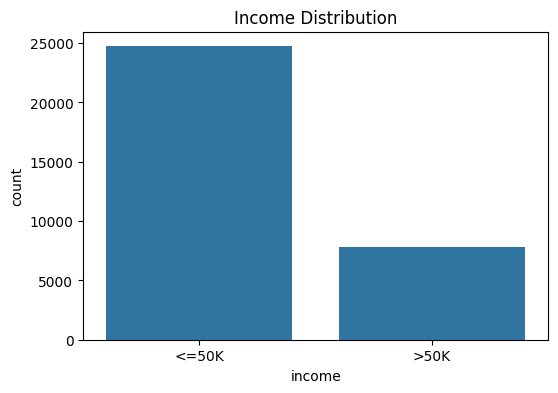

In [12]:
df["income"].value_counts()

plt.figure(figsize=(6,4))

sns.countplot(
    x="income",
    data=df
)

plt.title("Income Distribution")
plt.show()

Distribusi Gender

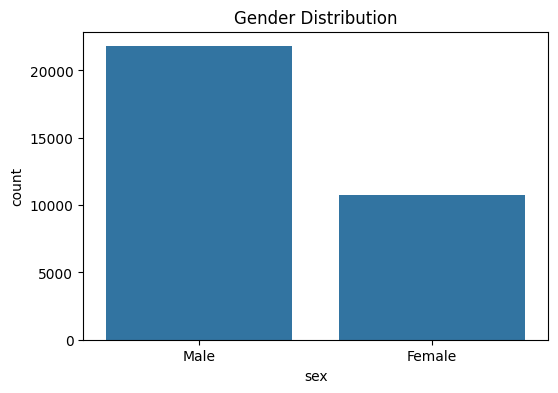

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="sex",
    data=df
)

plt.title("Gender Distribution")
plt.show()

Distribusi Education

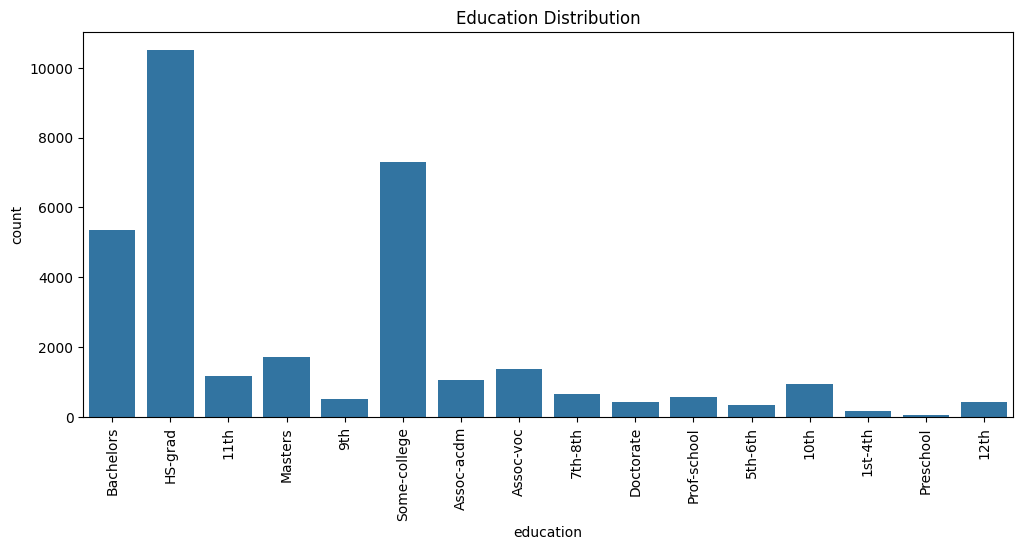

In [14]:
plt.figure(figsize=(12,5))

sns.countplot(
    x="education",
    data=df
)

plt.xticks(rotation=90)

plt.title("Education Distribution")
plt.show()

Distribusi Workclass

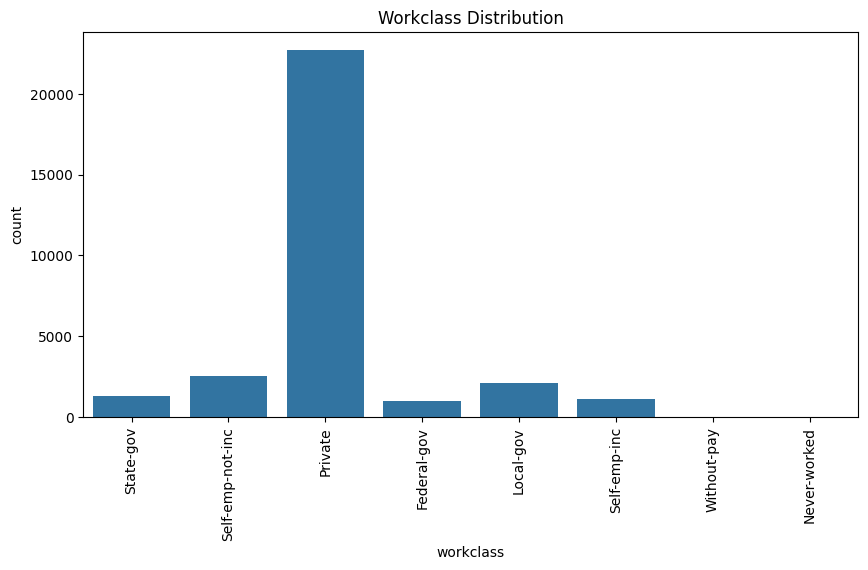

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="workclass",
    data=df
)

plt.xticks(rotation=90)

plt.title("Workclass Distribution")
plt.show()

Korelasi Fitur Numerik

In [16]:
numeric_cols = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week"
]

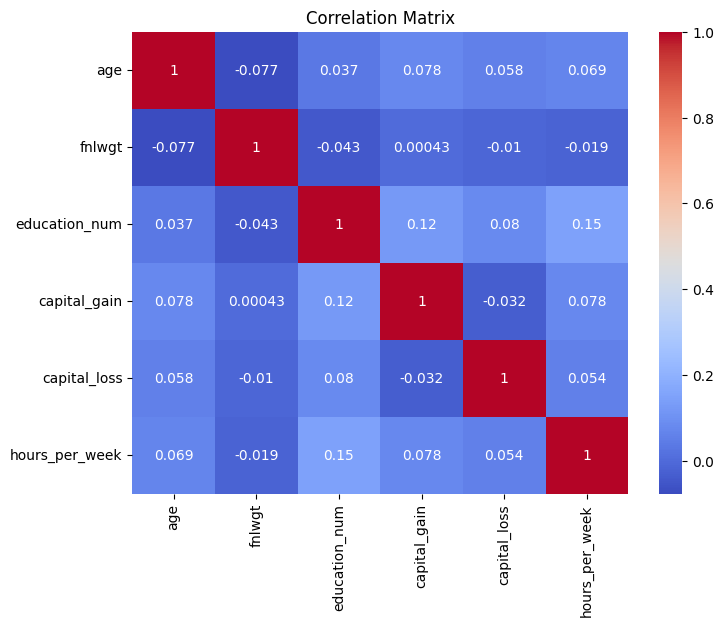

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

Visualisasi Outlier

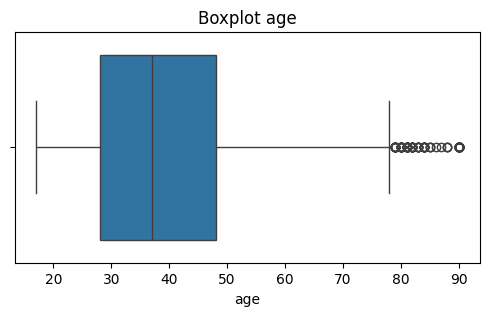

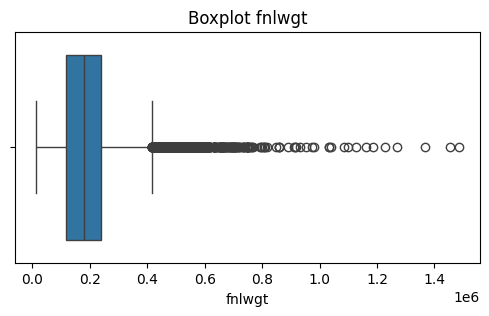

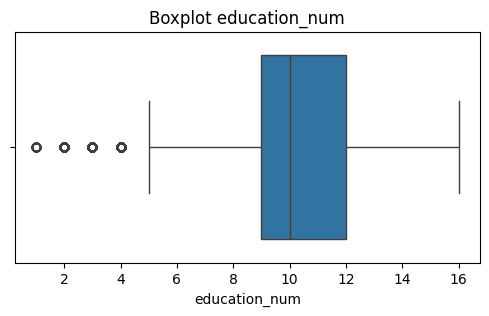

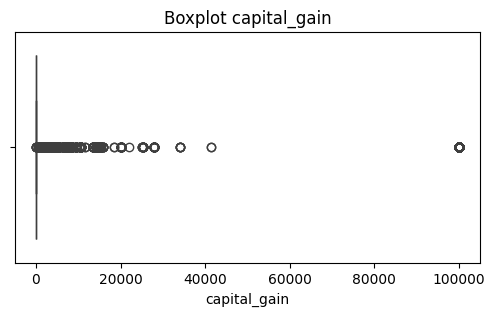

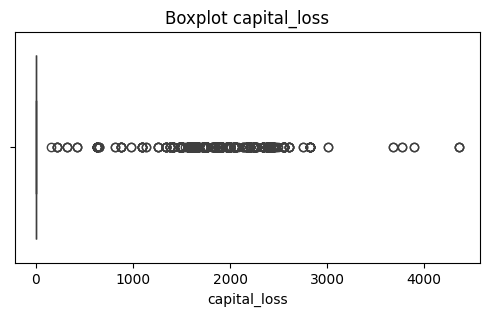

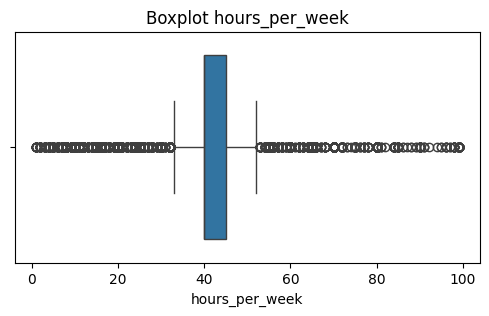

In [18]:
for col in numeric_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot {col}")

    plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

Menyimpan Shape Awal

In [19]:
original_shape = df.shape

print(original_shape)

(32561, 15)


Missing Value Handling

In [20]:
df.dropna(inplace=True)

Verifikasi Missing Value

In [21]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Menghapus Duplikasi

In [22]:
print("Sebelum:", len(df))

df.drop_duplicates(inplace=True)

print("Sesudah:", len(df))

Sebelum: 30162
Sesudah: 30139


One Hot Encoding

In [23]:
categorical_columns = [
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native_country"
]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

Encode Target

In [24]:
df["income"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

In [25]:
df["income"] = df["income"].replace({
    "<=50K.": 0,
    ">50K.": 1,
    "<=50K": 0,
    ">50K": 1
})

Pisahkan Fitur dan Target

In [26]:
X = df.drop(
    "income",
    axis=1
)

y = df["income"]

Feature Scaling

In [27]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

Menyimpan Scaler

In [28]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

Dataset Hasil Preprocessing

In [29]:
processed_df = X_scaled.copy()

processed_df["income"] = y.values

processed_df.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia,income
0,0.042516,-1.062676,1.128996,0.145925,-0.218673,-0.078031,-0.271352,-1.681420,-0.192228,-0.300621,...,-0.060247,-0.019108,-0.048593,-0.037356,-0.023757,-0.024446,0.310615,-0.04613,-0.023047,0
1,0.880215,-1.007829,1.128996,-0.147502,-0.218673,-2.332060,-0.271352,-1.681420,-0.192228,3.326447,...,-0.060247,-0.019108,-0.048593,-0.037356,-0.023757,-0.024446,0.310615,-0.04613,-0.023047,0
2,-0.033639,0.244669,-0.440434,-0.147502,-0.218673,-0.078031,-0.271352,0.594735,-0.192228,-0.300621,...,-0.060247,-0.019108,-0.048593,-0.037356,-0.023757,-0.024446,0.310615,-0.04613,-0.023047,0
3,1.108678,0.425206,-1.225149,-0.147502,-0.218673,-0.078031,-0.271352,0.594735,-0.192228,-0.300621,...,-0.060247,-0.019108,-0.048593,-0.037356,-0.023757,-0.024446,0.310615,-0.04613,-0.023047,0
4,-0.795183,1.406572,1.128996,-0.147502,-0.218673,-0.078031,-0.271352,0.594735,-0.192228,-0.300621,...,-0.060247,-0.019108,-0.048593,-0.037356,-0.023757,-0.024446,-3.219415,-0.04613,-0.023047,0


Verifikasi Dataset Akhir

In [30]:
processed_df.info()
processed_df.describe()
processed_df.shape

<class 'pandas.DataFrame'>
RangeIndex: 30139 entries, 0 to 30138
Data columns (total 97 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        30139 non-null  float64
 1   fnlwgt                                     30139 non-null  float64
 2   education_num                              30139 non-null  float64
 3   capital_gain                               30139 non-null  float64
 4   capital_loss                               30139 non-null  float64
 5   hours_per_week                             30139 non-null  float64
 6   workclass_Local-gov                        30139 non-null  float64
 7   workclass_Private                          30139 non-null  float64
 8   workclass_Self-emp-inc                     30139 non-null  float64
 9   workclass_Self-emp-not-inc                 30139 non-null  float64
 10  workclass_State-gov              

(30139, 97)

Menyimpan Dataset

In [31]:
processed_df.to_csv(
    "adult_income_preprocessed.csv",
    index=False
)

Verifikasi File Tersimpan

In [32]:
saved_df = pd.read_csv(
    "adult_income_preprocessed.csv"
)

saved_df.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia,income
0,0.042516,-1.062676,1.128996,0.145925,-0.218673,-0.078031,-0.271352,-1.681420,-0.192228,-0.300621,...,-0.060247,-0.019108,-0.048593,-0.037356,-0.023757,-0.024446,0.310615,-0.04613,-0.023047,0
1,0.880215,-1.007829,1.128996,-0.147502,-0.218673,-2.332060,-0.271352,-1.681420,-0.192228,3.326447,...,-0.060247,-0.019108,-0.048593,-0.037356,-0.023757,-0.024446,0.310615,-0.04613,-0.023047,0
2,-0.033639,0.244669,-0.440434,-0.147502,-0.218673,-0.078031,-0.271352,0.594735,-0.192228,-0.300621,...,-0.060247,-0.019108,-0.048593,-0.037356,-0.023757,-0.024446,0.310615,-0.04613,-0.023047,0
3,1.108678,0.425206,-1.225149,-0.147502,-0.218673,-0.078031,-0.271352,0.594735,-0.192228,-0.300621,...,-0.060247,-0.019108,-0.048593,-0.037356,-0.023757,-0.024446,0.310615,-0.04613,-0.023047,0
4,-0.795183,1.406572,1.128996,-0.147502,-0.218673,-0.078031,-0.271352,0.594735,-0.192228,-0.300621,...,-0.060247,-0.019108,-0.048593,-0.037356,-0.023757,-0.024446,-3.219415,-0.04613,-0.023047,0


In [36]:
print(processed_df.isnull().sum().sum())

0


In [37]:
processed_df["income"].value_counts()

income
0    22633
1     7506
Name: count, dtype: int64

## Kesimpulan

Tahap preprocessing berhasil dilakukan terhadap Adult Income Dataset.

Langkah preprocessing yang diterapkan meliputi:

1. Penanganan missing value.
2. Penghapusan data duplikat.
3. One Hot Encoding pada fitur kategorikal.
4. Standardisasi fitur numerik menggunakan StandardScaler.
5. Penyimpanan objek scaler.
6. Penyimpanan dataset hasil preprocessing.

Dataset akhir terdiri dari 30.139 observasi dan 97 kolom yang siap digunakan untuk proses pelatihan model machine learning.